# Passive Radar Scenario Notebook V1

This notebook is the presentation-layer walkthrough for **Project v1**. It does not reimplement the radar algorithms inside notebook cells. Instead, it imports the tested modules from `src/radar_sim/` and uses them to explain and simulate the complete scenario set.

## Audience

This notebook is written for:

- a graduation-project supervisor,
- a reviewer looking for DSP/radar correctness,
- and the project owner during debugging and final defense preparation.

## Prerequisites

You should already be comfortable with:

- complex baseband signals,
- OFDM basics,
- FFT-based spectrum analysis,
- range-Doppler maps,
- and the idea of CFAR detection.

## Learning Goals

By the end of this notebook, the reader should be able to understand:

1. how the simulated reference and surveillance channels are built,
2. how target delay and Doppler are injected,
3. how the range-Doppler map is formed,
4. how CA-CFAR is used for detection,
5. and how the configured scenarios behave relative to their ground truth.


## Outline

1. Load the project configuration and helper modules.
2. Summarize the radar model and scenario catalog.
3. Review the mathematical signal model and processing chain.
4. Run one detailed example step by step.
5. Run every configured scenario.
6. Compare detections against the injected truth.
7. List pitfalls, interpretation rules, and suggested next extensions.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'configs' / 'default.yaml').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate Project v1 root from the current notebook working directory.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from radar_sim.channel import simulate_surveillance_matrix
from radar_sim.constants import load_app_config
from radar_sim.detection import ca_cfar_2d
from radar_sim.metrics import match_detection_to_truth, scenario_truth
from radar_sim.plotting import plot_processing_summary
from radar_sim.processing import process_reference_and_surveillance
from radar_sim.scenarios import get_scenario, list_scenarios
from radar_sim.waveform import generate_reference_matrix

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
APP_CONFIG = load_app_config(CONFIG_PATH)
RADAR = APP_CONFIG.radar
CFAR = APP_CONFIG.cfar
SCENARIO_KEYS = list_scenarios(APP_CONFIG)

print(f'Project root: {PROJECT_ROOT}')
print(f'Loaded config: {CONFIG_PATH.name}')
print(f'Scenarios: {SCENARIO_KEYS}')
print(f'Sample rate: {RADAR.sample_rate_hz/1e6:.2f} MHz')
print(f'Carrier frequency: {RADAR.carrier_frequency_hz/1e9:.2f} GHz')
print(f'Pulses per CPI: {RADAR.num_pulses}')
print(f'Subcarriers: {RADAR.num_subcarriers}')
print(f'Cyclic prefix: {RADAR.cyclic_prefix}')


Project root: /home/mo/dev/python/HDDS2/Project v1
Loaded config: default.yaml
Scenarios: ['clear_sky', 'low_snr', 'single_fast', 'single_slow', 'two_targets']
Sample rate: 20.00 MHz
Carrier frequency: 2.40 GHz
Pulses per CPI: 128
Subcarriers: 256
Cyclic prefix: 64


## Radar Configuration Summary

The simulation uses a communication-like OFDM waveform and converts it into a radar sensing experiment. The most important parameters are:

- `sample_rate_hz`: controls delay resolution,
- `carrier_frequency_hz`: controls wavelength and velocity conversion,
- `pri_s`: controls slow-time Doppler sampling,
- `num_pulses`: controls coherent processing interval,
- `num_subcarriers` and `cyclic_prefix`: define the OFDM pulse structure.

The project currently reports **bistatic range excess** from delay and **velocity** from Doppler through the wavelength relation.


In [2]:
def show_radar_summary() -> None:
    wavelength = RADAR.wavelength_m
    range_bin_m = RADAR.speed_of_light / RADAR.sample_rate_hz
    doppler_bin_hz = 1.0 / (RADAR.num_pulses * RADAR.pri_s)
    velocity_bin_mps = wavelength * doppler_bin_hz / 2.0

    print('Radar parameter summary')
    print(f'  Wavelength: {wavelength:.6f} m')
    print(f'  Samples per pulse: {RADAR.samples_per_pulse}')
    print(f'  Useful symbol length: {RADAR.num_subcarriers}')
    print(f'  Approximate range-bin spacing: {range_bin_m:.2f} m')
    print(f'  Doppler-bin spacing: {doppler_bin_hz:.2f} Hz')
    print(f'  Velocity-bin spacing: {velocity_bin_mps:.2f} m/s')
    print(f'  Direct-path amplitude: {RADAR.direct_path_amplitude_db:.1f} dB')
    print(f'  Default clutter amplitude: {RADAR.clutter_amplitude_db:.1f} dB')
    print(f'  Default noise power: {RADAR.noise_power_db:.1f} dB')

show_radar_summary()


Radar parameter summary
  Wavelength: 0.125000 m
  Samples per pulse: 320
  Useful symbol length: 256
  Approximate range-bin spacing: 15.00 m
  Doppler-bin spacing: 31.25 Hz
  Velocity-bin spacing: 1.95 m/s
  Direct-path amplitude: -35.0 dB
  Default clutter amplitude: -45.0 dB
  Default noise power: -75.0 dB


## Scenario Catalog

Each scenario changes the target list and noise/clutter stress while keeping the main processing chain fixed. This is important: a scenario comparison is only meaningful when the DSP pipeline is held constant and only the environment changes.


In [3]:
def show_scenario_catalog() -> None:
    print('Available scenarios')
    print('-' * 88)
    print(f"{'Key':<16} {'Targets':<8} {'Noise(dB)':<12} {'Clutter(dB)':<14} Name")
    print('-' * 88)
    for key in SCENARIO_KEYS:
        scenario = get_scenario(APP_CONFIG, key)
        print(
            f"{key:<16} {len(scenario.targets):<8} "
            f"{scenario.noise_power_db:<12.1f} {scenario.clutter_amplitude_db:<14.1f} {scenario.name}"
        )

show_scenario_catalog()


Available scenarios
----------------------------------------------------------------------------------------
Key              Targets  Noise(dB)    Clutter(dB)    Name
----------------------------------------------------------------------------------------
clear_sky        0        -75.0        -45.0          Clear Sky
low_snr          1        -82.0        -45.0          Low SNR Weak Target
single_fast      1        -75.0        -45.0          Single Fast Target
single_slow      1        -75.0        -45.0          Single Slow Target
two_targets      2        -75.0        -45.0          Two Targets


## Signal Model

The simulation uses a **reference channel** and a **surveillance channel**.

### Reference Channel

The reference channel contains the transmitted OFDM-like waveform. In simulation, this is known exactly and is used for matched processing.

### Surveillance Channel

The surveillance signal is modeled as:

\[
 y[n, p] = a_{direct} x[n, p] + \sum_k a_k x[n-d_k, p] e^{j 2 \pi f_{d,k} t[n,p]} + c[n,p] + w[n,p]
\]

Where:

- \(x[n,p]\) is the reference pulse,
- \(a_{direct}\) is direct-path leakage,
- \(d_k\) is target delay,
- \(f_{d,k}\) is target Doppler,
- \(c[n,p]\) is clutter,
- \(w[n,p]\) is complex Gaussian noise.

### Physical Interpretation

- Delay controls where the target appears on the range axis.
- Doppler controls where the target appears on the Doppler axis.
- Direct path and clutter create strong stationary content around zero Doppler.


## Processing Chain

The implemented DSP chain follows these stages:

1. Remove cyclic prefix.
2. FFT the reference and surveillance signals.
3. Divide surveillance by reference to suppress data modulation.
4. IFFT along fast time to build range profiles.
5. Subtract the pulse mean to suppress stationary clutter and direct path.
6. FFT along slow time to form the range-Doppler map.
7. Apply CA-CFAR on power.

### Axis Definitions

The notebook uses:

- **bistatic range excess** from delay,
- **Doppler in Hz**,
- **velocity in m/s** from wavelength.

This is enough for a scientifically defensible simulation as long as the geometry assumption is stated clearly.


In [4]:
def run_scenario(scenario_key: str):
    scenario = get_scenario(APP_CONFIG, scenario_key)
    truths = scenario_truth(scenario, RADAR)
    rng = np.random.default_rng(APP_CONFIG.seed)

    reference = generate_reference_matrix(RADAR, rng)
    surveillance = simulate_surveillance_matrix(reference, RADAR, scenario, rng)
    processing = process_reference_and_surveillance(reference, surveillance, RADAR)
    detections = ca_cfar_2d(
        range_doppler_map=processing.range_doppler_map,
        range_axis_m=processing.range_axis_m,
        doppler_axis_hz=processing.doppler_axis_hz,
        velocity_axis_mps=processing.velocity_axis_mps,
        config=CFAR,
    )
    return scenario, truths, reference, surveillance, processing, detections


def print_truth_table(truths) -> None:
    if not truths:
        print('No truth targets in this scenario.')
        return

    print(f"{'#':<4} {'Range(m)':<12} {'Doppler(Hz)':<14} {'Velocity(m/s)':<16}")
    for idx, truth in enumerate(truths, start=1):
        print(
            f"{idx:<4} {truth.range_m:<12.2f} {truth.doppler_hz:<14.2f} {truth.velocity_mps:<16.2f}"
        )


def print_detection_table(detections, truths) -> None:
    if not detections.detections:
        print('No detections found by CA-CFAR.')
        return

    print(
        f"{'#':<4} {'Range(m)':<12} {'Doppler(Hz)':<14} {'Velocity(m/s)':<16} {'Peak(dB)':<12} Match"
    )
    for idx, item in enumerate(detections.detections, start=1):
        matched = match_detection_to_truth(
            detection=item,
            truths=truths,
            range_tolerance_m=30.0,
            doppler_tolerance_hz=25.0,
        )
        print(
            f"{idx:<4} {item.range_m:<12.2f} {item.doppler_hz:<14.2f} "
            f"{item.velocity_mps:<16.2f} {item.peak_power_db:<12.2f} {matched}"
        )


## Detailed Walkthrough: Single Slow Target

Before running all scenarios, it is useful to inspect one representative case carefully.

This scenario contains:

- one target,
- moderate noise,
- clutter and direct-path leakage,
- and a slow positive Doppler.

### What We Expect

If the chain is working correctly:

- the truth table should show one injected target,
- the range-Doppler map should contain one dominant moving-target response,
- and the CFAR output should report at least one detection near the truth bin.


Scenario: Single Slow Target
Truth targets
#    Range(m)     Doppler(Hz)    Velocity(m/s)   
1    1500.00      80.00          5.00            
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    1500.00      93.75          5.86             15.14        True
2    540.00       93.75          5.86             -11.84       False


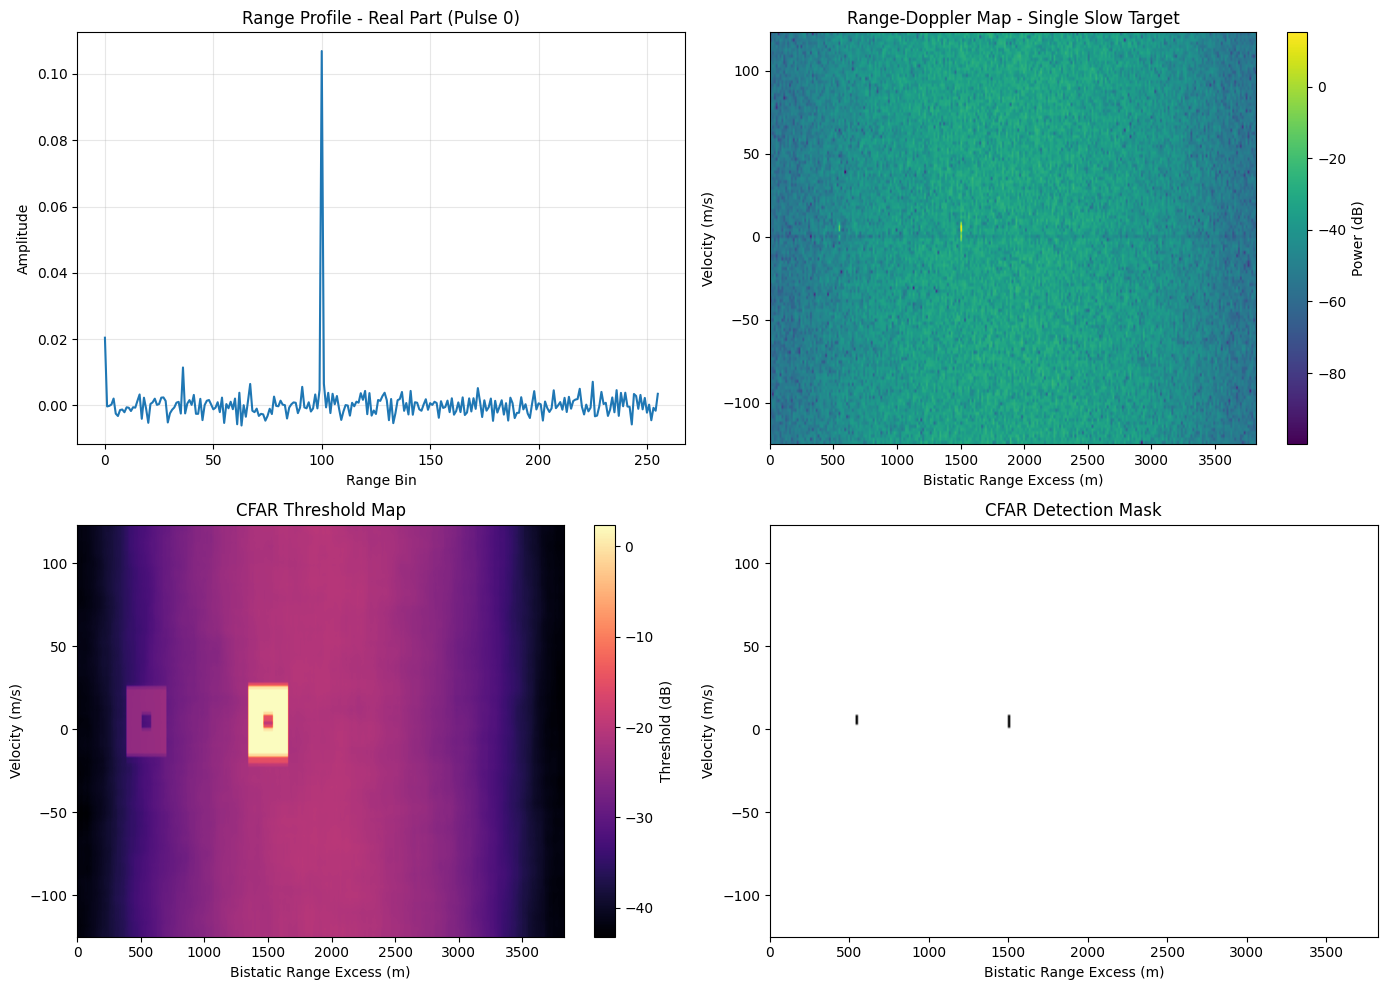

In [6]:
scenario, truths, reference, surveillance, processing, detections = run_scenario('single_slow')

print(f'Scenario: {scenario.name}')
print('Truth targets')
print_truth_table(truths)
print('Detections')
print_detection_table(detections, truths)

plot_processing_summary(processing, detections, scenario.name)


## Interpreting the Four Plots

### 1. Range Profile

This plot is a fast-time view after the reference compensation step. It is useful for checking whether delayed energy is present at all.

### 2. Range-Doppler Map

This is the main sensing product. A target should appear as a localized peak in:

- range, due to delay,
- Doppler/velocity, due to phase progression across pulses.

### 3. CFAR Threshold Map

This shows the adaptive threshold used by CA-CFAR. If it is too high, weak targets disappear. If it is too low, false alarms grow.

### 4. Detection Mask

This is the final binary decision layer. It should be sparse and physically interpretable.


## Run Every Scenario

The next cell runs the full scenario set defined in `configs/default.yaml`. Each scenario will:

1. generate a fresh reference matrix,
2. simulate a surveillance channel,
3. process the data into a range-Doppler map,
4. apply CA-CFAR,
5. print truth and detection summaries,
6. and show the plots.

This is the main notebook cell for system-level review.


SCENARIO KEY: clear_sky
SCENARIO NAME: Clear Sky
Truth targets
No truth targets in this scenario.
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    2175.00      125.00         7.81             -41.61       False


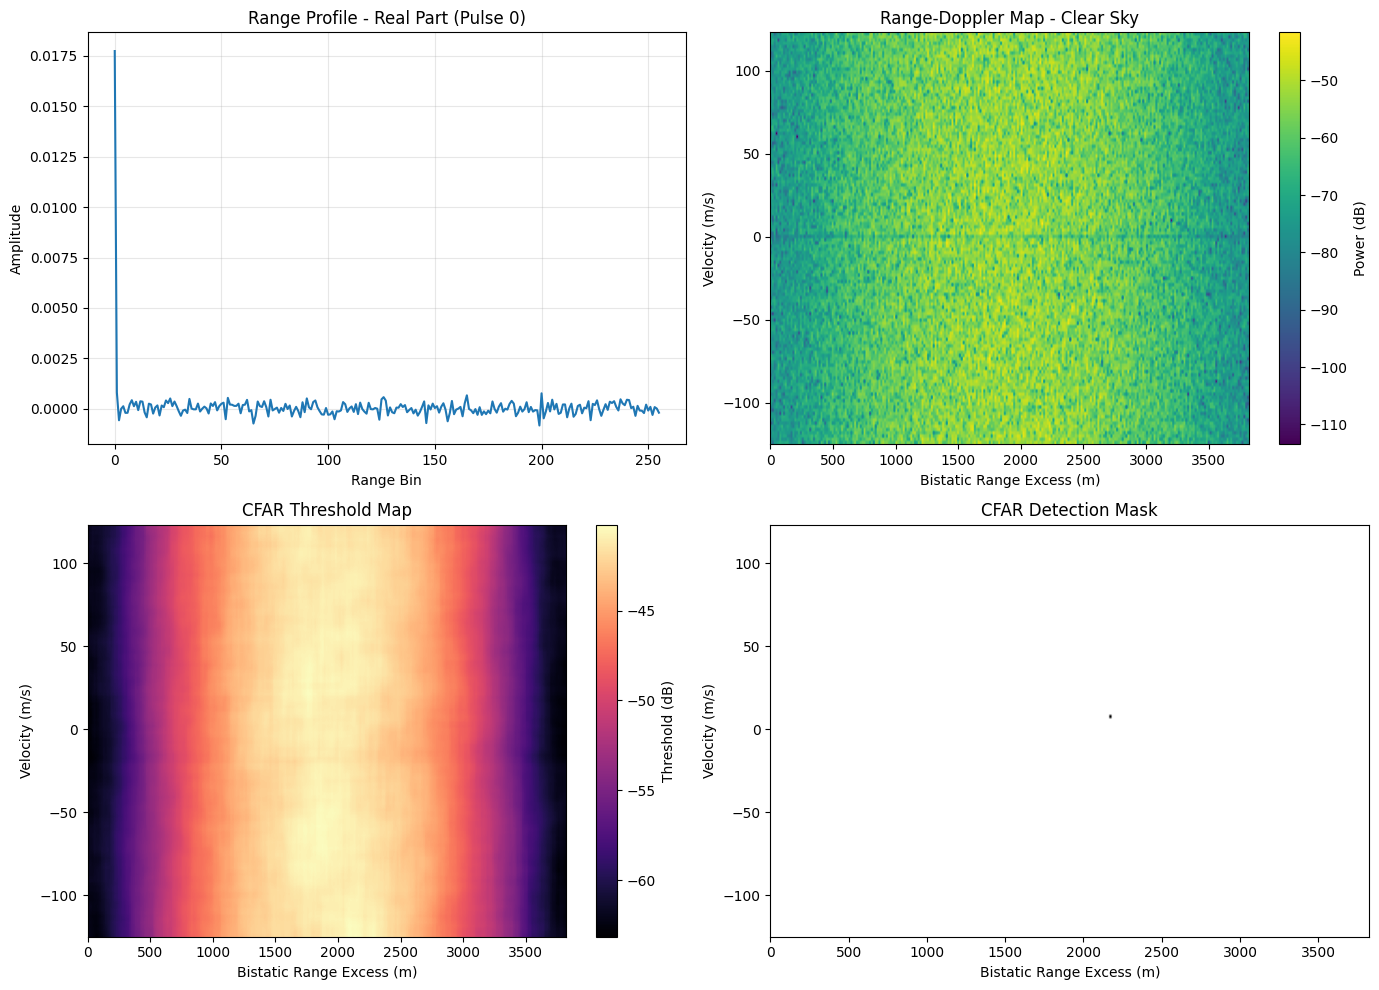

SCENARIO KEY: low_snr
SCENARIO NAME: Low SNR Weak Target
Truth targets
#    Range(m)     Doppler(Hz)    Velocity(m/s)   
1    1800.00      60.00          3.75            
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    1800.00      62.50          3.91             10.49        True
2    840.00       62.50          3.91             -7.37        False


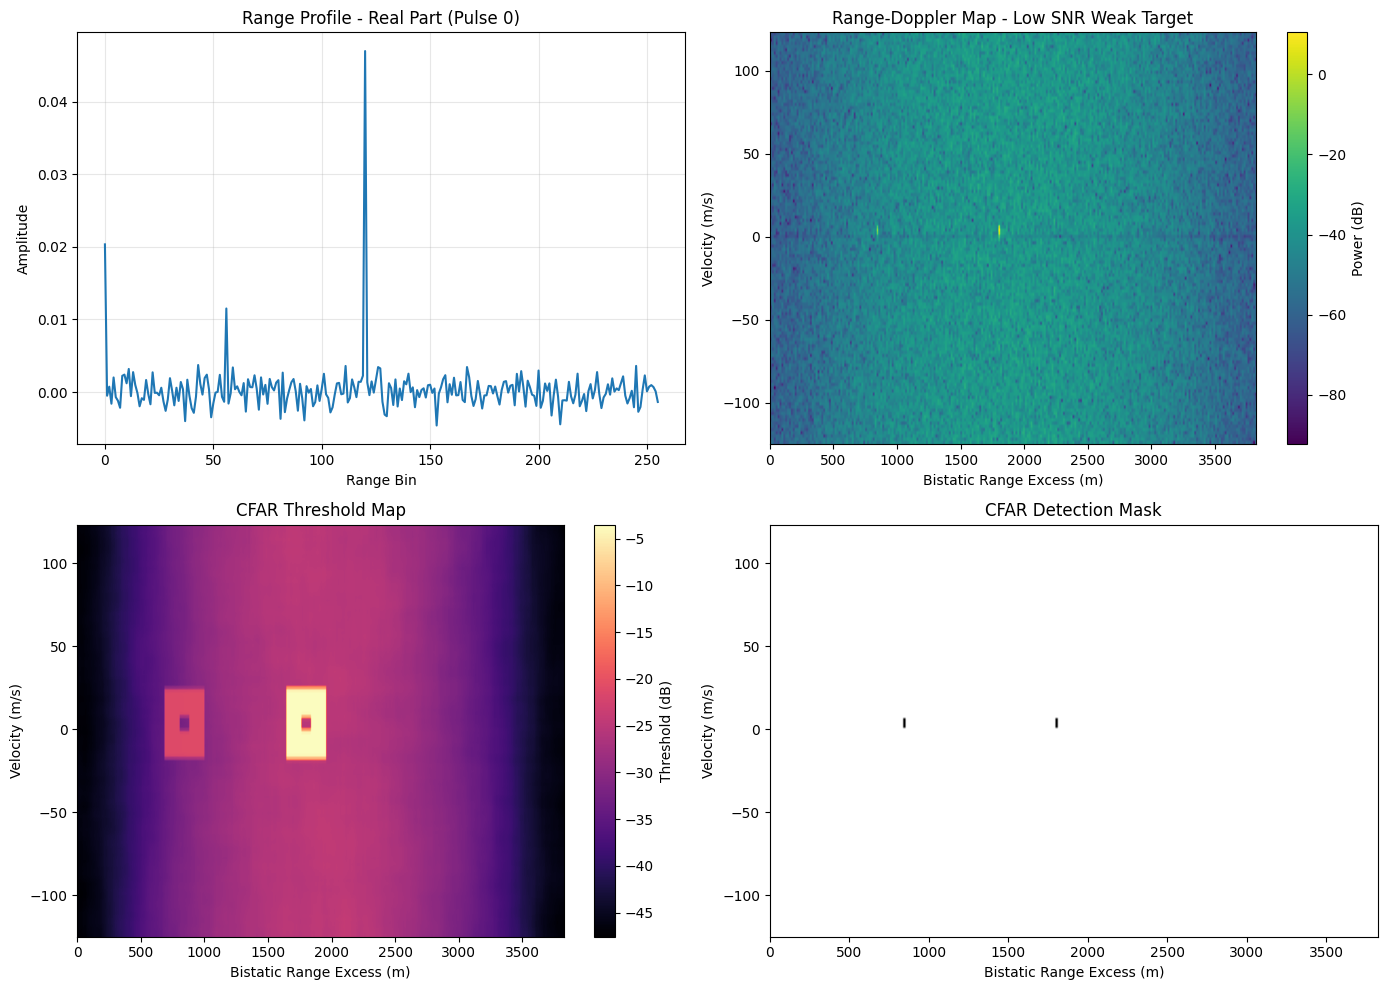

SCENARIO KEY: single_fast
SCENARIO NAME: Single Fast Target
Truth targets
#    Range(m)     Doppler(Hz)    Velocity(m/s)   
1    2400.00      -350.00        -21.88          
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    2400.00      -343.75        -21.48           15.07        True
2    1440.00      -343.75        -21.48           10.67        False


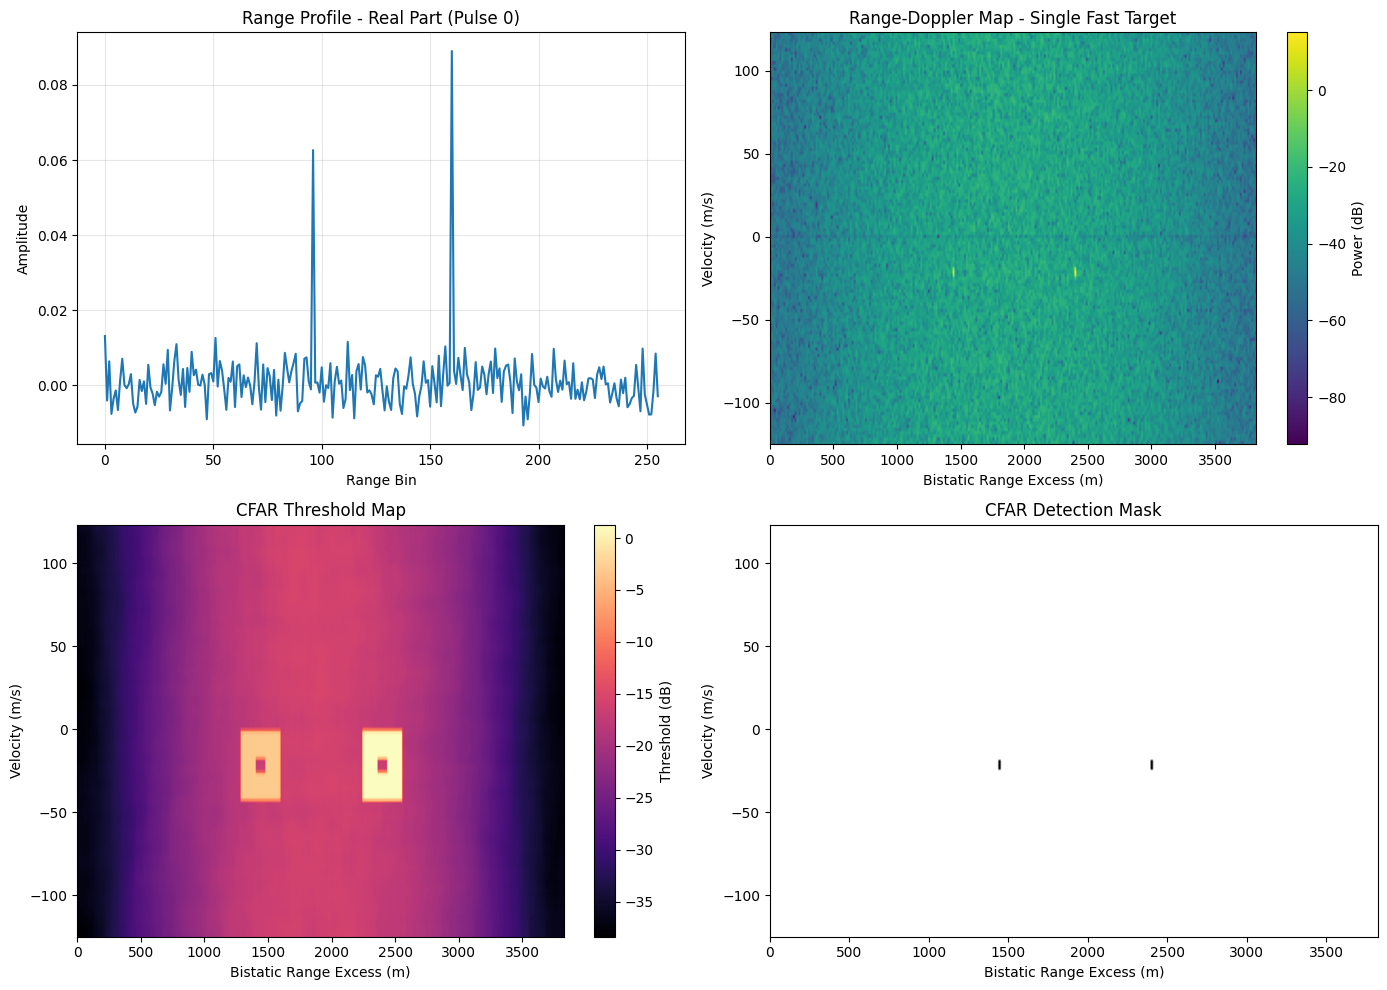

SCENARIO KEY: single_slow
SCENARIO NAME: Single Slow Target
Truth targets
#    Range(m)     Doppler(Hz)    Velocity(m/s)   
1    1500.00      80.00          5.00            
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    1500.00      93.75          5.86             15.14        True
2    540.00       93.75          5.86             -11.84       False


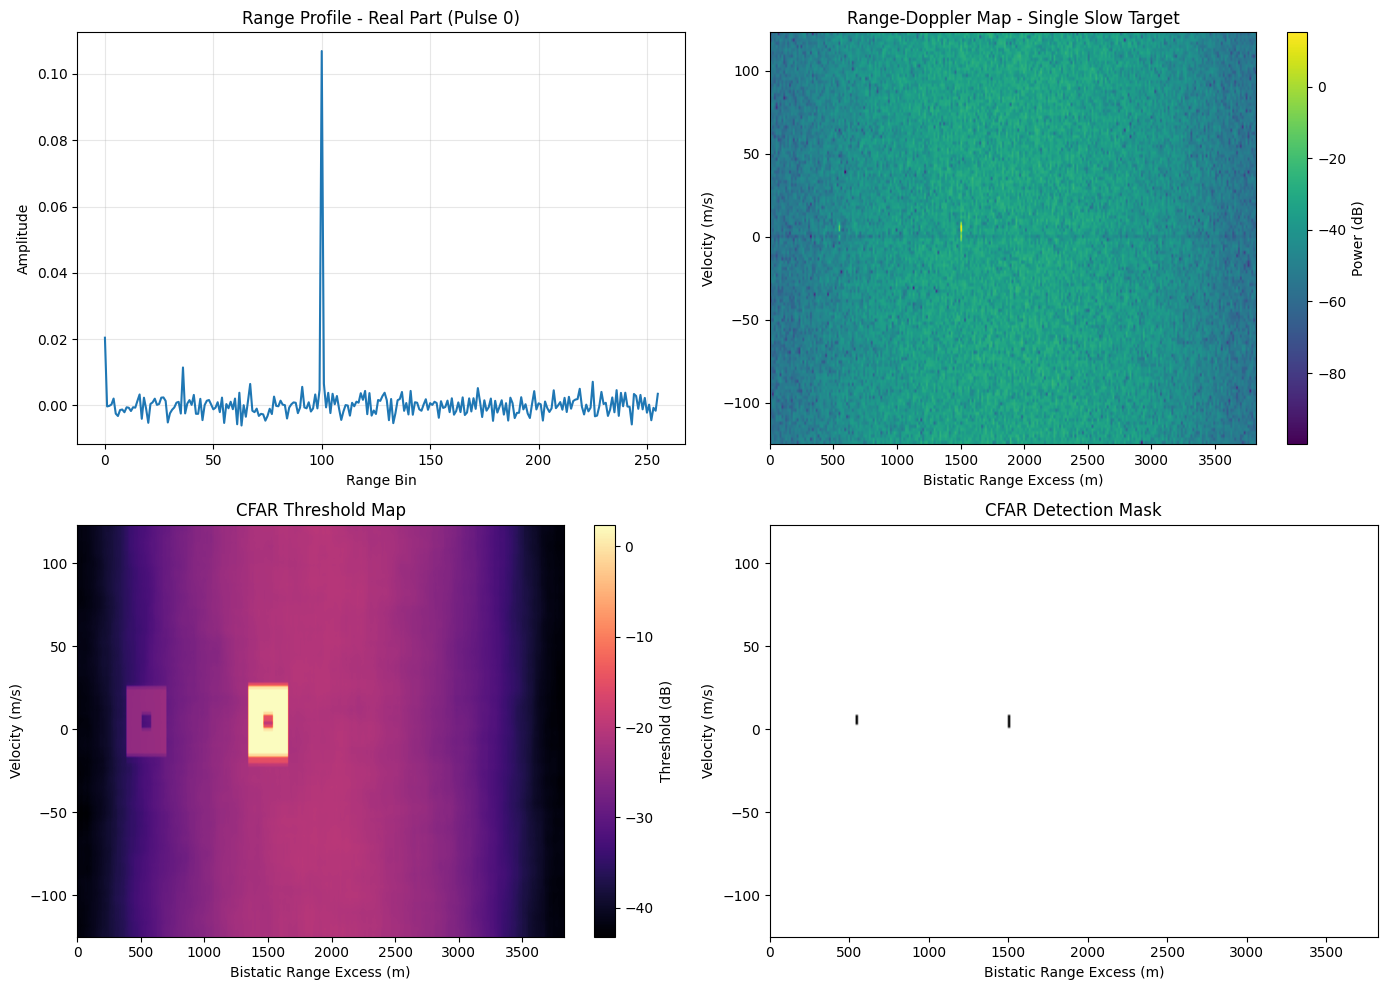

SCENARIO KEY: two_targets
SCENARIO NAME: Two Targets
Truth targets
#    Range(m)     Doppler(Hz)    Velocity(m/s)   
1    1350.00      120.00         7.50            
2    2100.00      -180.00        -11.25          
Detections
#    Range(m)     Doppler(Hz)    Velocity(m/s)    Peak(dB)     Match
1    1350.00      125.00         7.81             15.89        True
2    2100.00      -187.50        -11.72           13.15        True
3    1140.00      -187.50        -11.72           2.28         False
4    390.00       125.00         7.81             -16.81       False


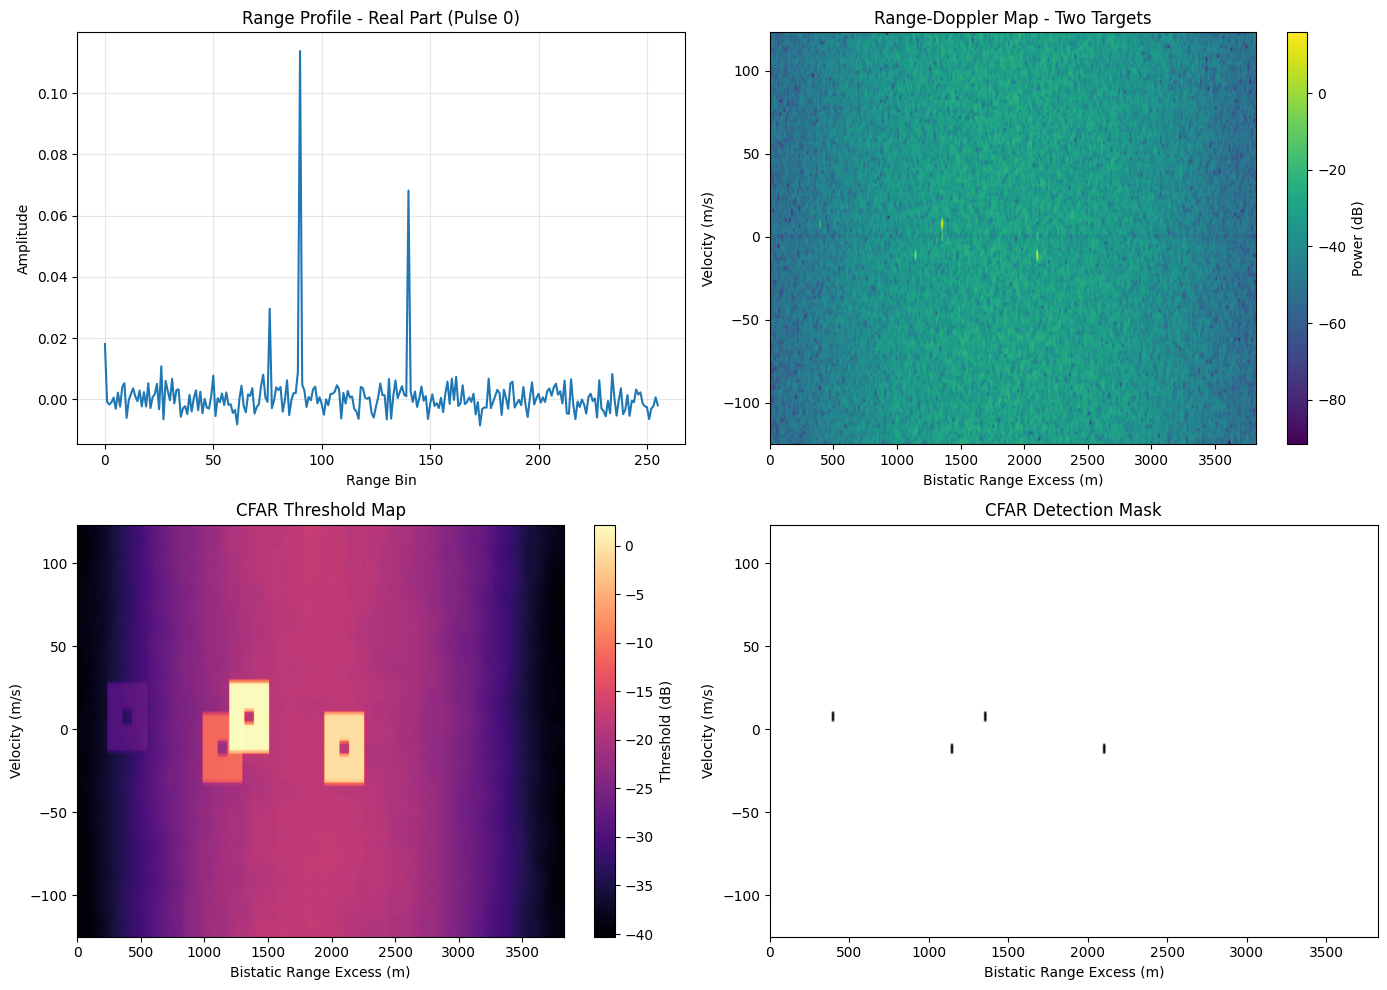

In [7]:
all_results = []

for scenario_key in SCENARIO_KEYS:
    scenario, truths, reference, surveillance, processing, detections = run_scenario(scenario_key)
    print('' + '=' * 100)
    print(f'SCENARIO KEY: {scenario_key}')
    print(f'SCENARIO NAME: {scenario.name}')
    print('=' * 100)
    print('Truth targets')
    print_truth_table(truths)
    print('Detections')
    print_detection_table(detections, truths)

    plot_processing_summary(processing, detections, scenario.name)

    matched_count = sum(
        match_detection_to_truth(
            detection=item,
            truths=truths,
            range_tolerance_m=30.0,
            doppler_tolerance_hz=25.0,
        )
        for item in detections.detections
    )

    all_results.append(
        {
            'key': scenario_key,
            'name': scenario.name,
            'truth_targets': len(truths),
            'detections': len(detections.detections),
            'matched_detections': int(matched_count),
            'max_power_db': float(10.0 * np.log10(np.max(detections.power_map) + 1.0e-18)),
        }
    )


## Scenario Summary Table

The next cell compresses the system behavior into a short summary. It is not a substitute for the full plots, but it helps compare the scenarios quickly.


In [8]:
print(f"{'Key':<16} {'Truth':<8} {'Detect':<8} {'Matched':<10} {'MaxPower(dB)':<14} Name")
print('-' * 88)
for row in all_results:
    print(
        f"{row['key']:<16} {row['truth_targets']:<8} {row['detections']:<8} "
        f"{row['matched_detections']:<10} {row['max_power_db']:<14.2f} {row['name']}"
    )


Key              Truth    Detect   Matched    MaxPower(dB)   Name
----------------------------------------------------------------------------------------
clear_sky        0        1        0          -41.61         Clear Sky
low_snr          1        2        1          10.49          Low SNR Weak Target
single_fast      1        2        1          15.07          Single Fast Target
single_slow      1        2        1          15.14          Single Slow Target
two_targets      2        4        2          15.89          Two Targets


## How To Judge Correctness

A scenario is behaving correctly when the following conditions hold:

### Clear Sky

- no truth targets,
- very few or ideally no strong detections,
- no stable off-zero peak that looks like a real target.

### Single-Target Scenarios

- one truth target,
- one dominant detection close to the injected delay and Doppler,
- no large set of equally strong false alarms.

### Two-Target Scenario

- two distinct responses should be visible,
- the detections should not collapse into a single merged solution unless the targets are too close for the chosen resolution.

### Low-SNR Scenario

- the target may be weaker,
- the threshold map matters more,
- and this case is the best stress test for CFAR tuning.


## Common Pitfalls

1. **Calling the range axis monostatic range without saying so.**  
   This notebook uses delay-derived bistatic range excess. That assumption must stay explicit.

2. **Trusting CFAR blindly.**  
   A detection mask is only meaningful if the threshold map and the raw range-Doppler map agree visually.

3. **Changing several parameters at once.**  
   When debugging, change only one of: noise, clutter, delay, Doppler, or amplitude.

4. **Treating the notebook as the codebase.**  
   The notebook is only the explanation layer. Core logic should remain in `src/radar_sim/`.


## Suggested Extensions

Good next technical upgrades after this notebook are:

1. add a clutter-stressed scenario with stronger stationary interference,
2. compare mean-subtraction MTI against a more explicit high-pass slow-time filter,
3. tune CFAR guard and training cells per scenario,
4. add a final notebook section that exports key figures to `results/`,
5. and, if needed, decide whether the thesis language will remain **passive radar** or be reframed more precisely as **OFDM sensing simulation**.


## Local Validation Checklist

After installing the dependencies, run this notebook top-to-bottom and check:

- the setup cell imports cleanly,
- the scenario catalog loads from YAML,
- each scenario produces plots,
- the summary table is populated,
- and the detections are at least qualitatively close to the injected truth.

If a scenario behaves badly, the first files to inspect are:

- `src/radar_sim/channel.py`
- `src/radar_sim/processing.py`
- `src/radar_sim/detection.py`
